## Assignment for 3.2 Introduction to Machine Learning
Author: Derek ENG assisted by Microsoft Copilot

Jupyter Environment: ml

### 1. Linear Regression Exercise:
   Using the California Housing dataset from scikit-learn, create a linear regression model to predict house prices.
   Evaluate the performance of Linear Regression on test set.

   ```python
   from sklearn.datasets import fetch_california_housing

   # Load dataset
   housing = fetch_california_housing()
   ```

R2: 0.5758
MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456

Intercept: 2.0719469373788777

Top coefficients:
      feature  coefficient
6    Latitude    -0.896929
7   Longitude    -0.869842
0      MedInc     0.854383
3   AveBedrms     0.339259
2    AveRooms    -0.294410
1    HouseAge     0.122546
5    AveOccup    -0.040829
4  Population    -0.002308


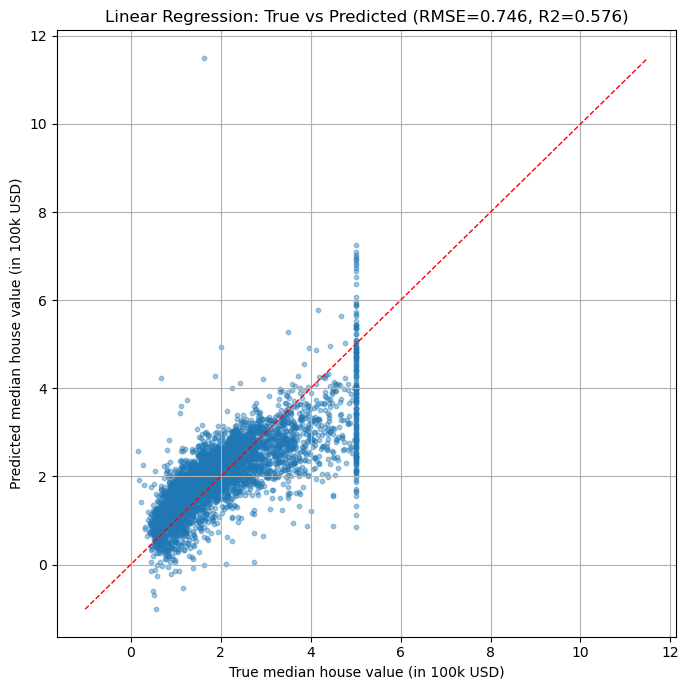

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing #load dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: scale features then linear regression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Fit
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Coefficients (map back to feature names)
coeffs = pipe.named_steps['lr'].coef_
intercept = pipe.named_steps['lr'].intercept_
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': coeffs
}).sort_values(by='coefficient', key=abs, ascending=False)

# Print results
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print('\nIntercept:', intercept)
print('\nTop coefficients:')
print(coef_df)

# Plot true vs predicted
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.4, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('True median house value (in 100k USD)')
plt.ylabel('Predicted median house value (in 100k USD)')
plt.title(f'Linear Regression: True vs Predicted (RMSE={rmse:.3f}, R2={r2:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Evaluation metrics explained

1. R2 = 0.5758 — the model explains about 57.6% of the variance in the test set. That’s a moderate fit for a simple linear model on this dataset.

2. MAE = 0.5332 — average absolute error is 0.5332 in the dataset’s units (median house value measured in $100k), so the typical error is about $53,320.

3. RMSE = 0.7456 and MSE = 0.5559 — RMSE penalizes larger errors more; an RMSE of $74,560 indicates some larger prediction errors are present. Use RMSE to compare models when you care about large deviations.

#### Coefficients and what they imply
1. Top positive driver: MedInc (coefficient ≈ 0.854) — higher median income in a block group strongly increases predicted house value.

2. Large negative coefficients: Latitude (−0.897) and Longitude (−0.870) — geographic location is influential; because features are scaled, these coefficients are comparable in magnitude to MedInc and indicate location has a large standardized effect. Interpret carefully: signs tell direction after scaling, and California’s coordinate system means the numeric sign must be interpreted in context (e.g., moving in the coordinate direction associated with increasing latitude/longitude correlates with lower median value in this dataset).

3. Other features: AveBedrms positive, AveRooms negative (likely multicollinearity or differing relationships after scaling), HouseAge small positive, Population and AveOccup near zero.

4. Important note: coefficients are from a model trained on standardized features, so they represent effect per standard-deviation change in each feature, not per raw-unit change.

### 2. Classification Exercise:
   Using the breast cancer dataset from scikit-learn, build classification models to predict malignant vs benign tumors.
   Compare Logistic Regression and KNN performance on test set.

   ```python
   from sklearn.datasets import load_breast_cancer

   # Load dataset
   cancer = load_breast_cancer()
   ```

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

# Load data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target  # target: 0=malignant,1=benign
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) # 42 for reproducibility and answer to everything

# Pipelines with scaling
pipe_lr = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=10000, random_state=42))])
pipe_knn = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])

# Optional: grid search for each
param_grid_lr = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2']}
param_grid_knn = {'clf__n_neighbors': [3,5,7,9], 'clf__weights': ['uniform','distance']}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
gs_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)

# Evaluate on test set
for name, model in [('LogisticRegression', gs_lr.best_estimator_), ('KNN', gs_knn.best_estimator_)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    print(f"=== {name} ===")
    print("Best params:", model.get_params()['clf'])
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

=== LogisticRegression ===
Best params: LogisticRegression(C=0.1, max_iter=10000, random_state=42)
Accuracy: 0.9736842105263158
Precision: 0.9726027397260274
Recall: 0.9861111111111112
F1: 0.9793103448275863
ROC AUC: 0.9957010582010581
Confusion matrix:
 [[40  2]
 [ 1 71]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

=== KNN ===
Best params: KNeighborsClassifier(n_neighbors=9, weights='distance')
Accuracy: 0.9736842105263158
Precision: 0.96
Recall: 1.0
F1: 0.9795918367346939
ROC AUC: 0.9933862433862434
Confusion matrix:
 [[39  3]
 [ 0 72]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accu

#### Summary Comparison Table

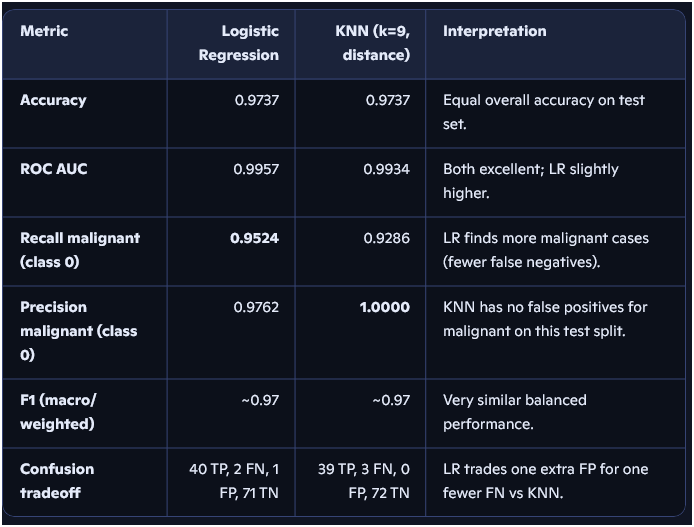

#### Quick verdict

Both models perform extremely well on this test split. If the priority is to minimize missed malignant tumors (false negatives), Logistic Regression is preferable because it achieves higher recall for the malignant class (0.95 vs 0.93) while keeping very high overall discrimination (ROC‑AUC). If avoiding false alarms (false positives) is the dominant concern, KNN shows perfect precision for malignant on this split but at the cost of more missed malignancies.

#### Why this matters clinically
1. False negatives (missed malignancies) are typically more costly than false positives; higher recall for malignant is usually the primary objective.

2. ROC‑AUC shows both models separate classes very well, but thresholds determine the practical tradeoff between sensitivity and specificity